In [1]:
out_dir = '/Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/ccm_memory/results/supplements/vlsm_convergence'

Enter the path to the dictionary generated by Notebook 01

In [2]:
dict_path = '/Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/ccm_memory/results/notebook_01/rois/tmp/dataset_dict_pruned.json'

# 01 - Begin Analysis

What correlation method would you like to use?
- Pearson is very fast, but depends on linearity and is sensitive to outliers
- Spearman is slower, but much more robust

One or Two-Tail P Values?

- ``` tails = 'one_tail' or tails = 'two_tail' ```

Numer of permutations? 
- Pearson is ~10x faster than Spearman

Would you like to compare maps wiht spearman or pearson?

- ``` method = 'spearman' or method = 'pearson' ```

Would you like to FWE correct the pairwise matrix?

- ``` fwe = True or fwe = False ```

In [3]:
tails = 'one_tail'
n_permutations = 100
method = 'pearson'
fwe = False
datasets_to_flip = []#'Alzheimer Disease', 'Multiple Sclerosis', 'Penetrating TBI']# ['Parietal TMS Hebscher'] #['adni_Alzheimer', 'corbetta_memory', 'manitoba_memory', 'ms_memory']

Run it

In [4]:
from calvin_utils.neuroimaging_utils.ccm_utils.ccm_correlation_analysis import CorrelationAnalysis
correlation_analysis = CorrelationAnalysis(data_dict_path=dict_path, 
                                           method=method, 
                                           datasets_to_flip=datasets_to_flip,
                                           n_permutations=n_permutations,
                                           out_dir=out_dir,
                                           topology_command=None)
p_value, pairwise_p_values = correlation_analysis.run(tails, fwe)

Running permutations: 100%|██████████| 100/100 [03:06<00:00,  1.87s/it]

Calculating one-tailed p-values
The observed average similarity is: 0.02672054893841857
The one_tail p-value is: 0.0. This is the proportion of permuted averages that are greater than the observed average.
Overall p-value: 0.0


# 02 - Visualize Results

Similarity matrix (Signs Included)

In [5]:
correlation_analysis.original_similarity_matrix

array([[ 1.00000000e+00, -2.03687377e-02,  6.53289900e-02,
        -2.29928671e-02, -7.88435076e-02,  4.43195646e-03,
         2.14633600e-03,  2.91040725e-03,  2.78482979e-03,
         3.70603266e-04,  4.33469497e-03,  5.61490120e-04,
         1.31855095e-03],
       [-2.03687377e-02,  1.00000000e+00, -1.81693988e-02,
        -7.60675791e-02,  1.06274419e-01, -1.19113677e-02,
        -6.28283580e-03, -5.94279471e-03, -7.46697790e-03,
        -6.45926598e-05, -1.41836235e-02,  6.49871431e-04,
        -2.34835866e-04],
       [ 6.53289900e-02, -1.81693988e-02,  1.00000000e+00,
        -8.95721111e-03, -3.82079042e-02, -6.08734247e-04,
        -8.81790463e-06, -3.97132923e-04,  1.48493699e-02,
        -2.04825088e-03,  3.52180687e-04, -4.48921207e-03,
        -1.05274587e-03],
       [-2.29928671e-02, -7.60675791e-02, -8.95721111e-03,
         1.00000000e+00, -8.27629817e-03, -6.41834248e-03,
        -8.37877796e-04, -3.59156903e-03,  2.74128968e-03,
         3.91071424e-04,  6.51668134e

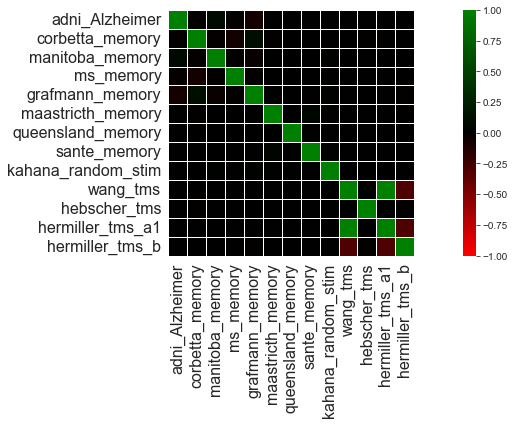

In [6]:
limit = correlation_analysis.matrix_heatmap(correlation_analysis.original_similarity_matrix, type='similarity', output_path=out_dir)

View the Overall Similarities of the Topology, Signs Aside

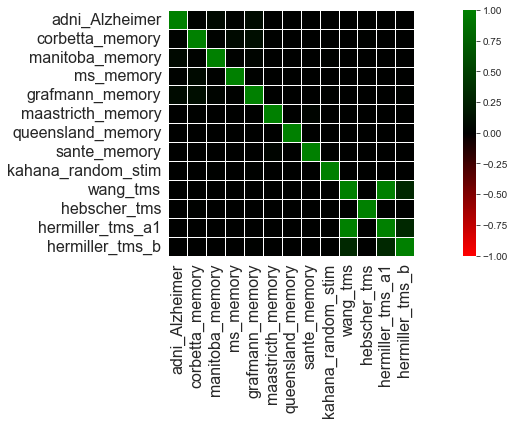

In [7]:
import numpy as np
limit = correlation_analysis.matrix_heatmap(np.abs(correlation_analysis.original_similarity_matrix), type='similarity', output_path=out_dir+'/heatmap_similarity_absval.svg')

Permuted Similarity

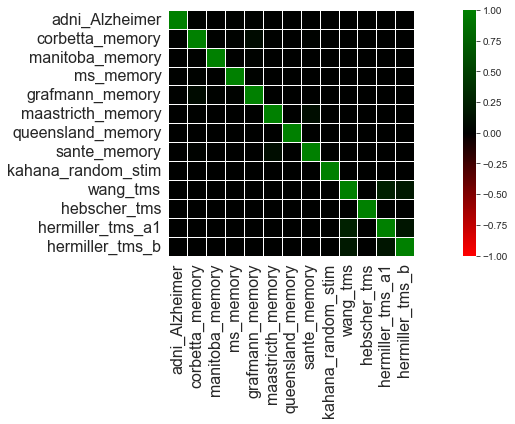

In [8]:
import numpy as np
avg_sim_mx = np.mean(np.abs(correlation_analysis.permuted_similarity_tensor), axis=0)
l = correlation_analysis.matrix_heatmap(avg_sim_mx, type='similarity', output_path=out_dir+'/heatmap_similarity_permuted.svg', limit=limit)

Pairwise P values Matrix

In [9]:
out_dir

'/Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/ccm_memory/results/supplements/vlsm_convergence'

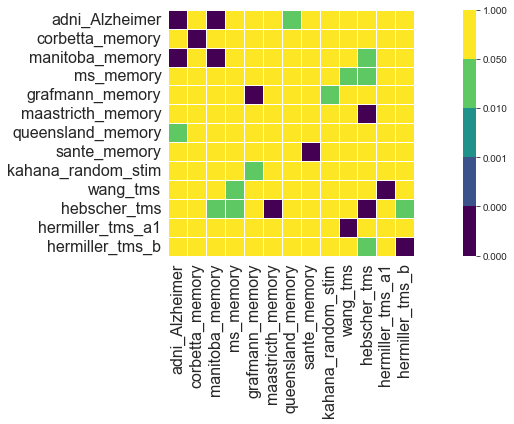

In [10]:
correlation_analysis.matrix_heatmap(pairwise_p_values, type='pvals', output_path=out_dir)

In [11]:
pairwise_p_values

array([[0.  , 0.85, 0.  , 0.96, 1.  , 0.22, 0.03, 0.37, 0.23, 0.5 , 0.17,
        0.53, 0.39],
       [0.85, 0.  , 0.81, 1.  , 0.11, 0.85, 0.82, 0.6 , 0.89, 0.63, 0.94,
        0.31, 0.67],
       [0.  , 0.81, 0.  , 0.9 , 0.96, 0.94, 0.5 , 0.82, 0.06, 0.77, 0.01,
        0.75, 0.78],
       [0.96, 1.  , 0.9 , 0.53, 0.69, 1.  , 0.81, 0.8 , 0.11, 0.02, 0.03,
        0.11, 0.97],
       [1.  , 0.11, 0.96, 0.69, 0.  , 0.36, 0.57, 0.29, 0.01, 0.23, 0.84,
        0.17, 0.98],
       [0.22, 0.85, 0.94, 1.  , 0.36, 0.59, 0.58, 0.35, 0.32, 0.14, 0.  ,
        0.24, 0.92],
       [0.03, 0.82, 0.5 , 0.81, 0.57, 0.58, 0.82, 0.45, 0.53, 0.51, 0.41,
        0.56, 0.5 ],
       [0.37, 0.6 , 0.82, 0.8 , 0.29, 0.35, 0.45, 0.  , 0.34, 0.32, 0.08,
        0.44, 0.82],
       [0.23, 0.89, 0.06, 0.11, 0.01, 0.32, 0.53, 0.34, 0.67, 0.59, 0.8 ,
        0.55, 0.4 ],
       [0.5 , 0.63, 0.77, 0.02, 0.23, 0.14, 0.51, 0.32, 0.59, 0.68, 0.91,
        0.  , 0.9 ],
       [0.17, 0.94, 0.01, 0.03, 0.84, 0.  , 0.41, 

# Optional - Run a Leave-One-Fold-Out Evaluation
- This assesses if any specific dataset or datasets are driving your effect

Define Parameters

In [12]:
# tails = 'two_tail'
# n_permutations = 1000
# method = 'spearman'
# fwe = False
# datasets_to_flip = []

Define folds as an array of lists. Each list is a fold which will be left out during the evaluation. 
- The names you can enter are in your JSON file, printed below

In [ ]:
# folds = [['ANT DBS SANTE', 'ANT DBS Maastricht', 'Epilepsy iEEG'], ['ANT DBS SANTE'], ['Alzheimer Disease'], ['Acute Stroke'], ['Multiple Sclerosis'], ['Penetrating TBI'], ['Parietal TMS Hebscher', 'Parietal TMS Wang', 'Parietal TMS Hermiller 2019a', 'Parietal TMS Hermiller 2019b']]

Run Evaluation

In [ ]:
# from calvin_utils.neuroimaging_utils.ccm_utils.ccm_correlation_analysis import CorrelationAnalysis
# correlation_analysis = CorrelationAnalysis(data_dict_path=dict_path, 
#                                            method=method, 
#                                            datasets_to_flip=[],
#                                            n_permutations=n_permutations,
#                                            out_dir=out_dir,
#                                            topology_command=None)
# p_value, pairwise_p_values = correlation_analysis.run_lofo(folds, tails, fwe)

# Optional - Evaluate P-Values Across Specific Slices of the Similarity Matrix

In [ ]:
# import numpy as np
# obsv = np.load('/Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/ccm_memory/results/notebook_02/redo2/conn/spearman/all_data/unaligned/original_similarity_matrix.npy')
# perm = np.load('/Users/cu135/Partners HealthCare Dropbox/Calvin Howard/studies/ccm_memory/results/notebook_02/redo2/conn/spearman/all_data/unaligned/permuted_similarity_tensor.npy')

In [ ]:
# from calvin_utils.neuroimaging_utils.ccm_utils.ccm_correlation_analysis import CorrelationAnalysis

# p, r = CorrelationAnalysis.calculate_slice_p_value(
#     obsv,
#     perm,
#     row_indices=[8,9,10,11],
#     col_indices=[8,9,10,11],
#     method='two_tail',
#     absolute_similarity=True,
#     remove_diagonal=True
# )
# print("p: ", p)
# print("r: ", r)